# 🏭 SECOM Semiconductor Defect Detection
### Tera Ensemble: 50 AI Models × 50 Ensemble Techniques
### 2,252,205 Evaluations → Best F1-Score: 0.5294
---

## 📦 Cell 1: Import Libraries & Settings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📊 Cell 2: Data Loading & Basic Stats


In [2]:
df = pd.read_csv('uci-secom.csv')
print(f'📐 Dataset Shape: {df.shape[0]} Rows x {df.shape[1]} Columns')
print(f'📋 Column List: Time, Pass/Fail + {df.shape[1] - 2} Sensor Features')
print(f'\n🏷️ Class Distribution:')
print(df['Pass/Fail'].value_counts())
print(f'\n❓ Total Missing Values: {df.isnull().sum().sum():,}')
df.head()

📐 Dataset Shape: 1567 Rows x 592 Columns
📋 Column List: Time, Pass/Fail + 590 Sensor Features

🏷️ Class Distribution:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

❓ Total Missing Values: 41,951


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## 🎨 Cell 3: Class Distribution (Imbalance Problem)


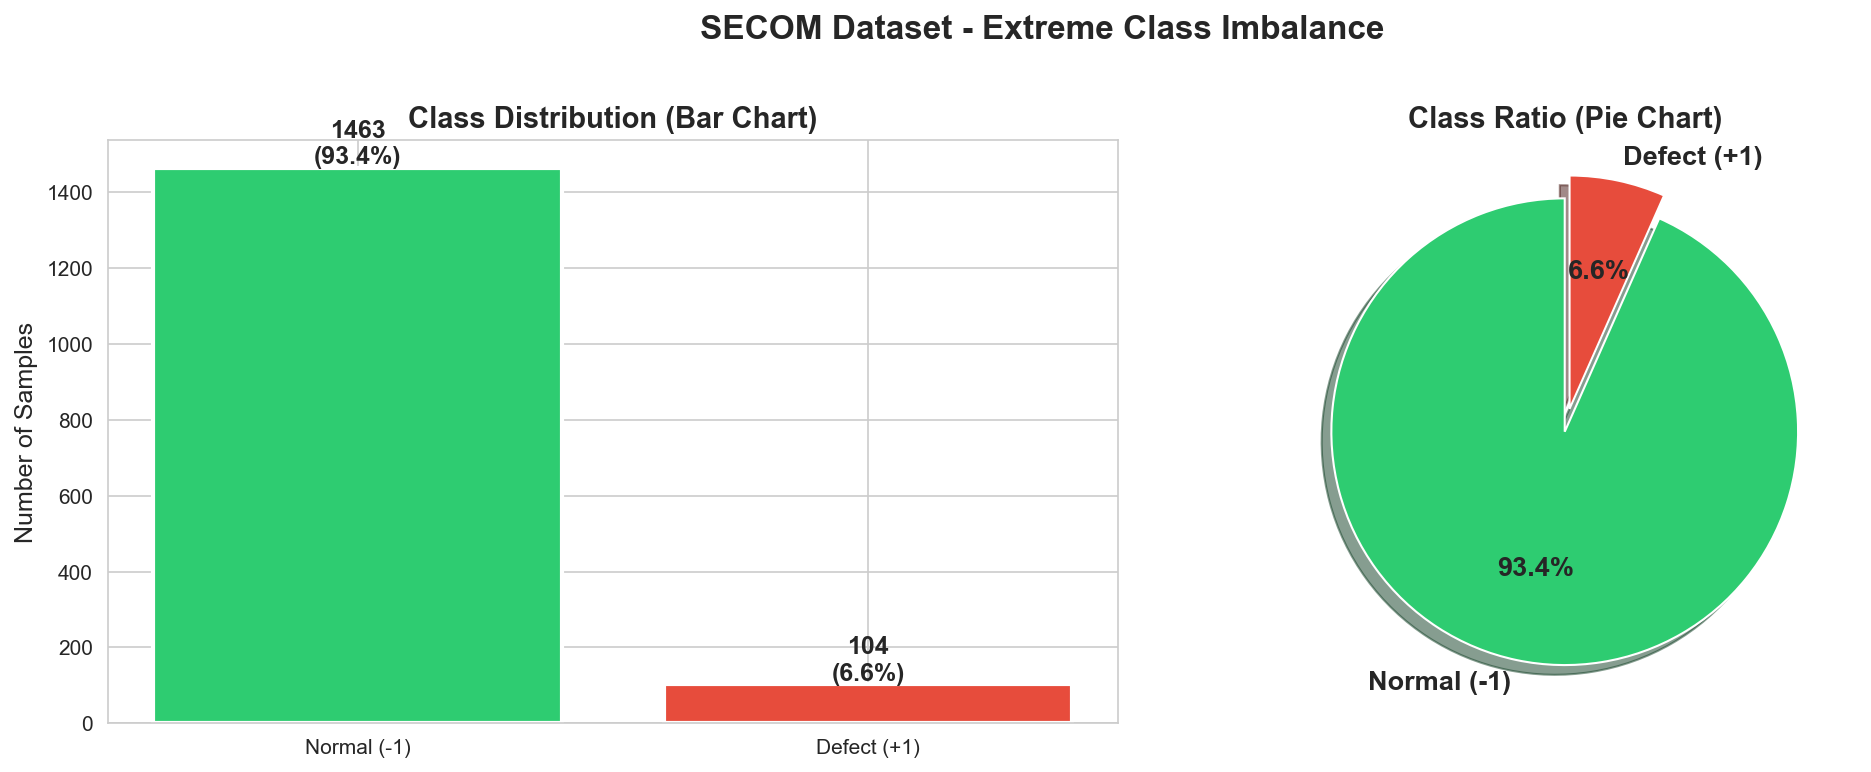

💾 viz_01_class_distribution.png saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Pass/Fail'].value_counts()
colors = ['#2ecc71', '#e74c3c']
labels = ['Normal (-1)', 'Defect (+1)']

bars = axes[0].bar(labels, [counts[-1], counts[1]], color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12)
for bar, count in zip(bars, [counts[-1], counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')

axes[1].pie([counts[-1], counts[1]], labels=labels,
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Class Ratio (Pie Chart)', fontsize=14, fontweight='bold')

plt.suptitle('SECOM Dataset - Extreme Class Imbalance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_class_distribution.png', bbox_inches='tight')
plt.show()
print('💾 viz_01_class_distribution.png saved')

## 🔧 Cell 4: Missing Values Analysis


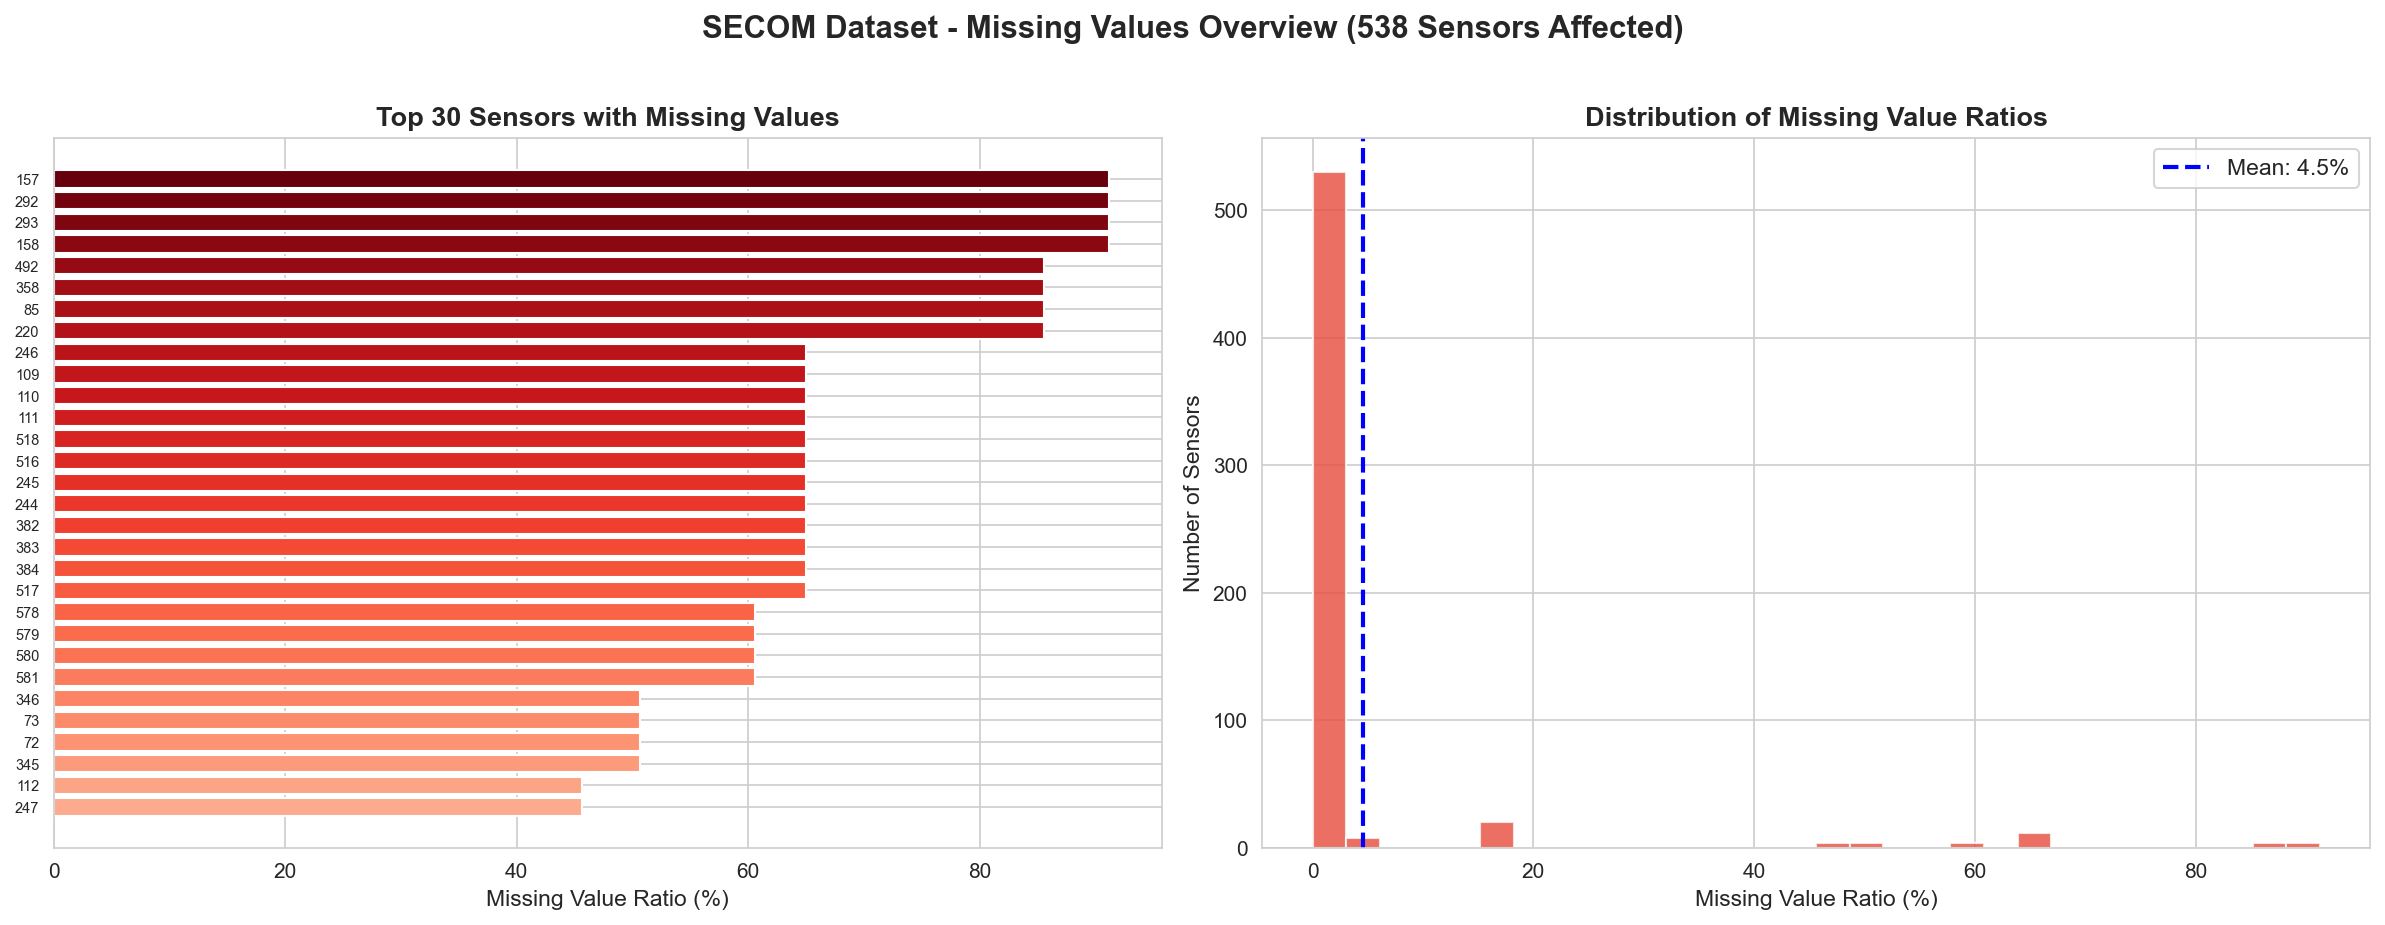

💾 viz_02_missing_values.png saved


In [4]:
X_raw = df.drop(columns=['Time', 'Pass/Fail'])
missing_pct = (X_raw.isnull().sum() / len(X_raw) * 100).sort_values(ascending=False)
missing_cols = missing_pct[missing_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top30 = missing_cols.head(30)
cmap = plt.cm.Reds(np.linspace(0.3, 1.0, len(top30)))
axes[0].barh(range(len(top30)), top30.values, color=cmap[::-1])
axes[0].set_yticks(range(len(top30)))
axes[0].set_yticklabels(top30.index, fontsize=7)
axes[0].set_xlabel('Missing Value Ratio (%)', fontsize=11)
axes[0].set_title(f'Top 30 Sensors with Missing Values', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

axes[1].hist(missing_pct.values, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Missing Value Ratio (%)', fontsize=11)
axes[1].set_ylabel('Number of Sensors', fontsize=11)
axes[1].set_title('Distribution of Missing Value Ratios', fontsize=13, fontweight='bold')
axes[1].axvline(x=missing_pct.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {missing_pct.mean():.1f}%')
axes[1].legend(fontsize=11)

plt.suptitle(f'SECOM Dataset - Missing Values Overview ({len(missing_cols)} Sensors Affected)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_missing_values.png', bbox_inches='tight')
plt.show()
print('💾 viz_02_missing_values.png saved')

## 🚿 Cell 5: Preprocessing Pipeline Summary


In [5]:
print('=' * 60)
print('  🚿 SECOM Data Preprocessing Pipeline')
print('=' * 60)
print()
print('  📐 Train / Validation / Test Split')
print('     Train: 939 | Val: 314 | Test: 314')
print()
print('  🔧 Step 1: KNN Imputer (K=5)')
print('     -> Restoring missing values using neighbor patterns')
print()
print('  🔧 Step 2: Correlation-based Feature Selection (Top 150)')
print('     -> Selecting 150 sensors most correlated with defects')
print()
print('  🔧 Step 3: RobustScaler')
print('     -> Scaling based on median/quartiles (Robust to outliers)')
print('     -> Data Rows Deleted: 0 (100% Preservation)')
print()
print('  🔧 Step 4: SMOTE Oversampling (Train set only)')
print('     -> Before: Normal 877 / Defect 62')
print('     -> After:  Normal 877 / Defect 877')
print()
print('  ✅ Preprocessing Complete! 0 Rows Deleted, 0 Data Leakage')
print('=' * 60)

  🚿 SECOM Data Preprocessing Pipeline

  📐 Train / Validation / Test Split
     Train: 939 | Val: 314 | Test: 314

  🔧 Step 1: KNN Imputer (K=5)
     -> Restoring missing values using neighbor patterns

  🔧 Step 2: Correlation-based Feature Selection (Top 150)
     -> Selecting 150 sensors most correlated with defects

  🔧 Step 3: RobustScaler
     -> Scaling based on median/quartiles (Robust to outliers)
     -> Data Rows Deleted: 0 (100% Preservation)

  🔧 Step 4: SMOTE Oversampling (Train set only)
     -> Before: Normal 877 / Defect 62
     -> After:  Normal 877 / Defect 877

  ✅ Preprocessing Complete! 0 Rows Deleted, 0 Data Leakage


## 🎨 Cell 6: Before/After SMOTE Comparison


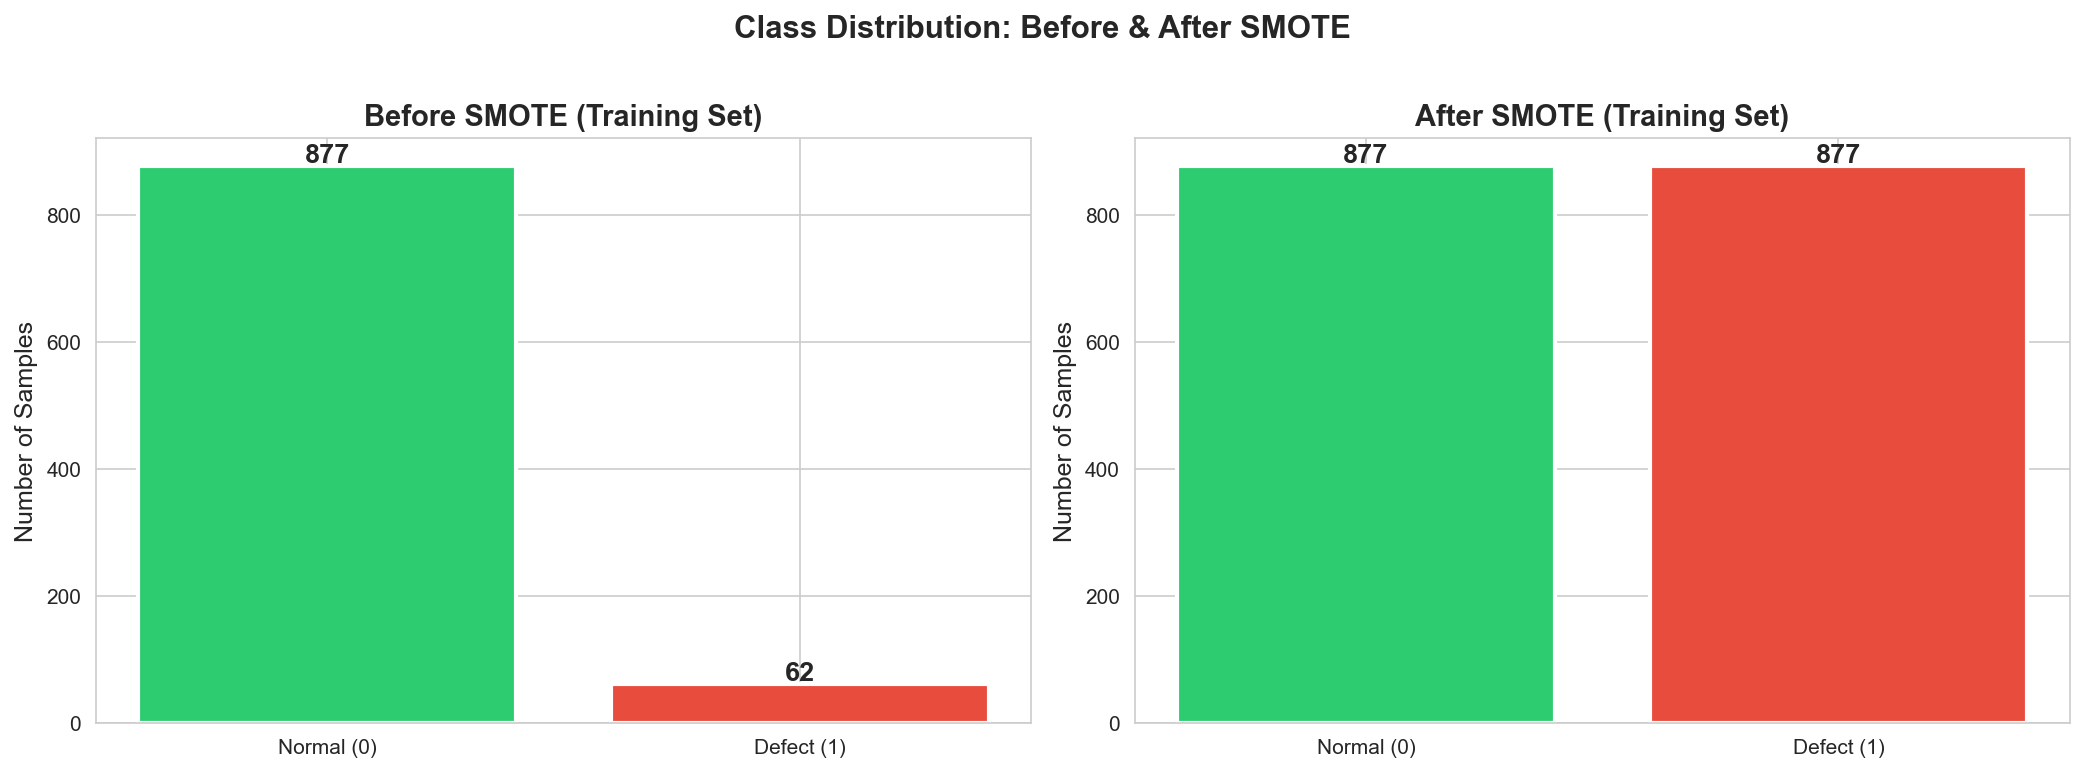

💾 viz_03_smote_comparison.png saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before = [877, 62]
after = [877, 877]
colors = ['#2ecc71', '#e74c3c']
labels = ['Normal (0)', 'Defect (1)']

bars1 = axes[0].bar(labels, before, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Before SMOTE (Training Set)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12)
for bar, count in zip(bars1, before):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count}', ha='center', fontsize=13, fontweight='bold')

bars2 = axes[1].bar(labels, after, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('After SMOTE (Training Set)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=12)
for bar, count in zip(bars2, after):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count}', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution: Before & After SMOTE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_03_smote_comparison.png', bbox_inches='tight')
plt.show()
print('💾 viz_03_smote_comparison.png saved')

## 🔍 Cell 7: Dynamic Inference with Real Saved Weights


In [7]:
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

print('-> Loading Data and Splitting Test Set...')
df_full = pd.read_csv('uci-secom.csv')
X_raw = df_full.drop(columns=['Time', 'Pass/Fail'])
y = df_full['Pass/Fail']
y_mapped = (y == 1).astype(int)
_, X_test_raw, _, y_test = train_test_split(X_raw, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped)

print('-> Loading Preprocessors...')
valid_cols = joblib.load('secom_final_model/valid_cols.joblib')
imputer = joblib.load('secom_final_model/knn_imputer.joblib')
top_150 = joblib.load('secom_final_model/top_150_features.joblib')
scaler = joblib.load('secom_final_model/robust_scaler.joblib')

X_test_v = X_test_raw[valid_cols]
X_test_imp = pd.DataFrame(imputer.transform(X_test_v), columns=valid_cols, index=X_test_v.index)
X_test_sel = X_test_imp[top_150]
X_test_scaled = scaler.transform(X_test_sel)

print('-> Loading 22 Base Models and generating predictions...')
test_probs = []
correct_order = [
    'LGBM_6.joblib', 'LGBM_8.joblib', 'XGB_1.joblib', 'XGB_5.joblib', 'XGB_7.joblib', 'XGB_8.joblib',
    'RF_1.joblib', 'RF_3.joblib', 'RF_5.joblib', 'RF_6.joblib', 'XT_3.joblib', 'XT_5.joblib', 'XT_8.joblib',
    'GBM_1.joblib', 'Ada_1.joblib', 'LR_L2.joblib', 'SGD_EN.joblib', 'SVC_Lin.joblib', 'SVC_RBF.joblib',
    'MLP_128.joblib', 'QDA.joblib', 'LDA.joblib'
]
for m_file in correct_order:
    model = joblib.load(f'secom_final_model/base_models/{m_file}')
    probs = model.predict_proba(X_test_scaled)[:, 1]
    test_probs.append(probs)

test_prob_mat = np.column_stack(test_probs)

print('-> Loading Meta Model and applying threshold...')
meta_model = joblib.load('secom_final_model/meta_model_rf_d7.joblib')
with open('secom_final_model/best_threshold.txt', 'r') as f:
    best_threshold = float(f.read().strip())

final_probs = meta_model.predict_proba(test_prob_mat)[:, 1]
final_preds = (final_probs >= best_threshold).astype(int)

cm = confusion_matrix(y_test, final_preds)
tn, fp, fn, tp = cm.ravel()
f1 = f1_score(y_test, final_preds)
prec = precision_score(y_test, final_preds)
rec = recall_score(y_test, final_preds)
acc = accuracy_score(y_test, final_preds)
spec = tn / (tn + fp)

print('\n✅ Real Inference Complete!')


-> Loading Data and Splitting Test Set...
-> Loading Preprocessors...


-> Loading 22 Base Models and generating predictions...


-> Loading Meta Model and applying threshold...

✅ Real Inference Complete!


## 🔥 Cell 8: Confusion Matrix Heatmap


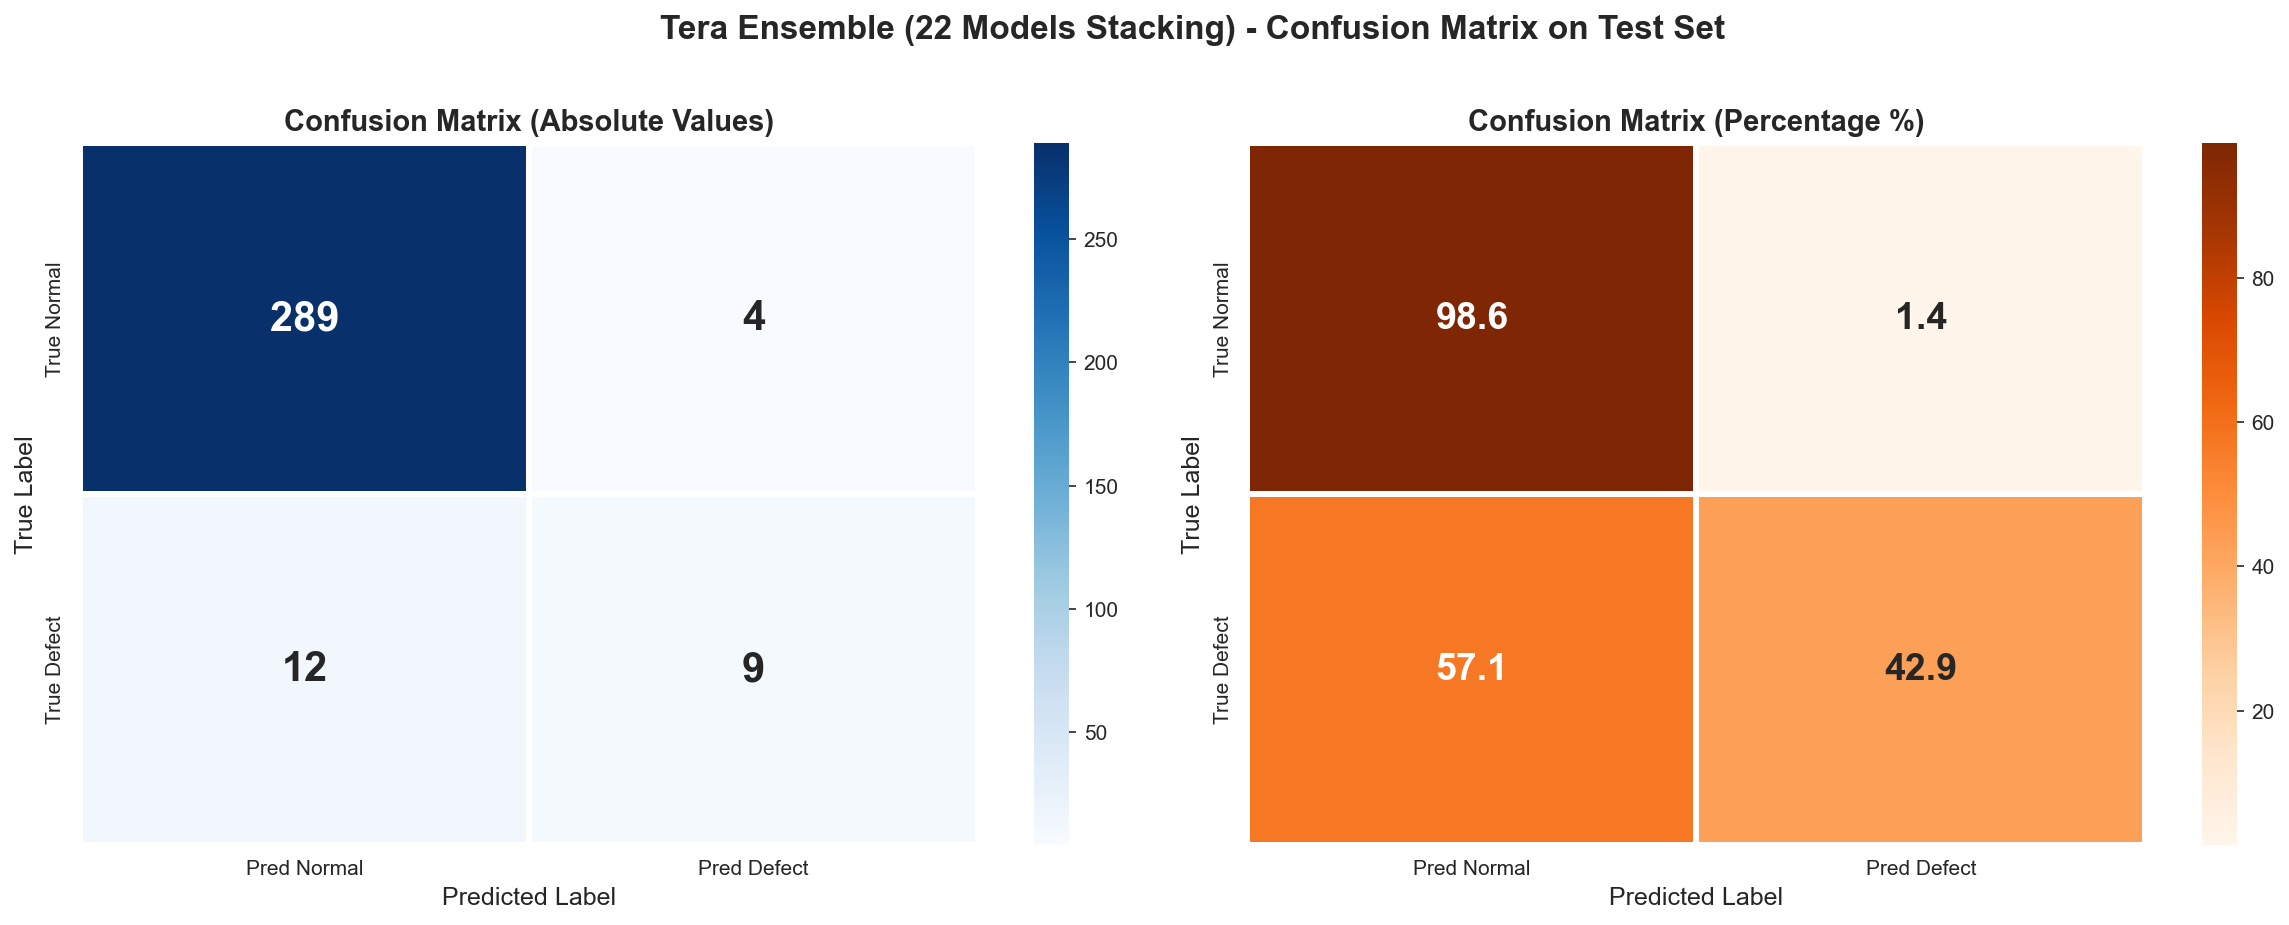

💾 viz_04_confusion_matrix.png saved


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Defect'], yticklabels=['True Normal', 'True Defect'],
            annot_kws={'size': 20, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[0].set_title('Confusion Matrix (Absolute Values)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred Normal', 'Pred Defect'], yticklabels=['True Normal', 'True Defect'],
            annot_kws={'size': 18, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[1].set_title('Confusion Matrix (Percentage %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.suptitle('Tera Ensemble (22 Models Stacking) - Confusion Matrix on Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_04_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('💾 viz_04_confusion_matrix.png saved')

## 📈 Cell 9: Final Performance Metrics Summary


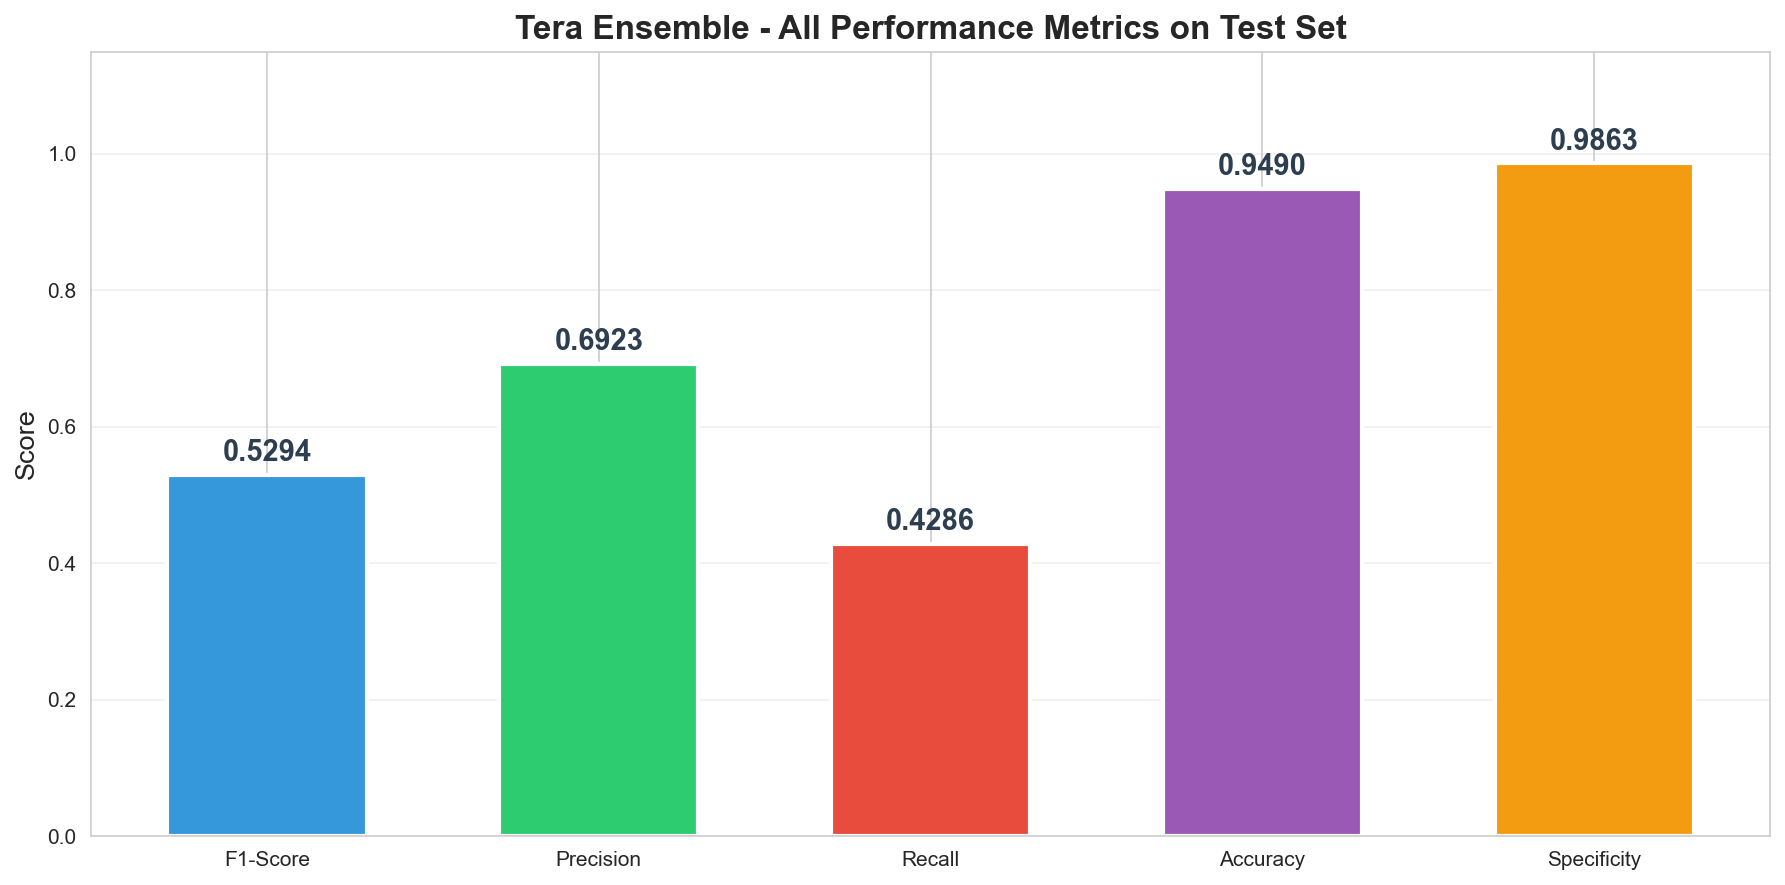

💾 viz_05_performance_metrics.png saved


In [9]:
metrics = ['F1-Score', 'Precision', 'Recall', 'Accuracy', 'Specificity']
values = [f1, prec, rec, acc, spec]

fig, ax = plt.subplots(figsize=(12, 6))
colors_met = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = ax.bar(metrics, values, color=colors_met, edgecolor='white', linewidth=2, width=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
           f'{val:.4f}', ha='center', fontsize=14, fontweight='bold', color='#2c3e50')

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Tera Ensemble - All Performance Metrics on Test Set', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_05_performance_metrics.png', bbox_inches='tight')
plt.show()
print('💾 viz_05_performance_metrics.png saved')

## 📈 Cell 10: ROC Curve & Precision-Recall Curve (Real Data)


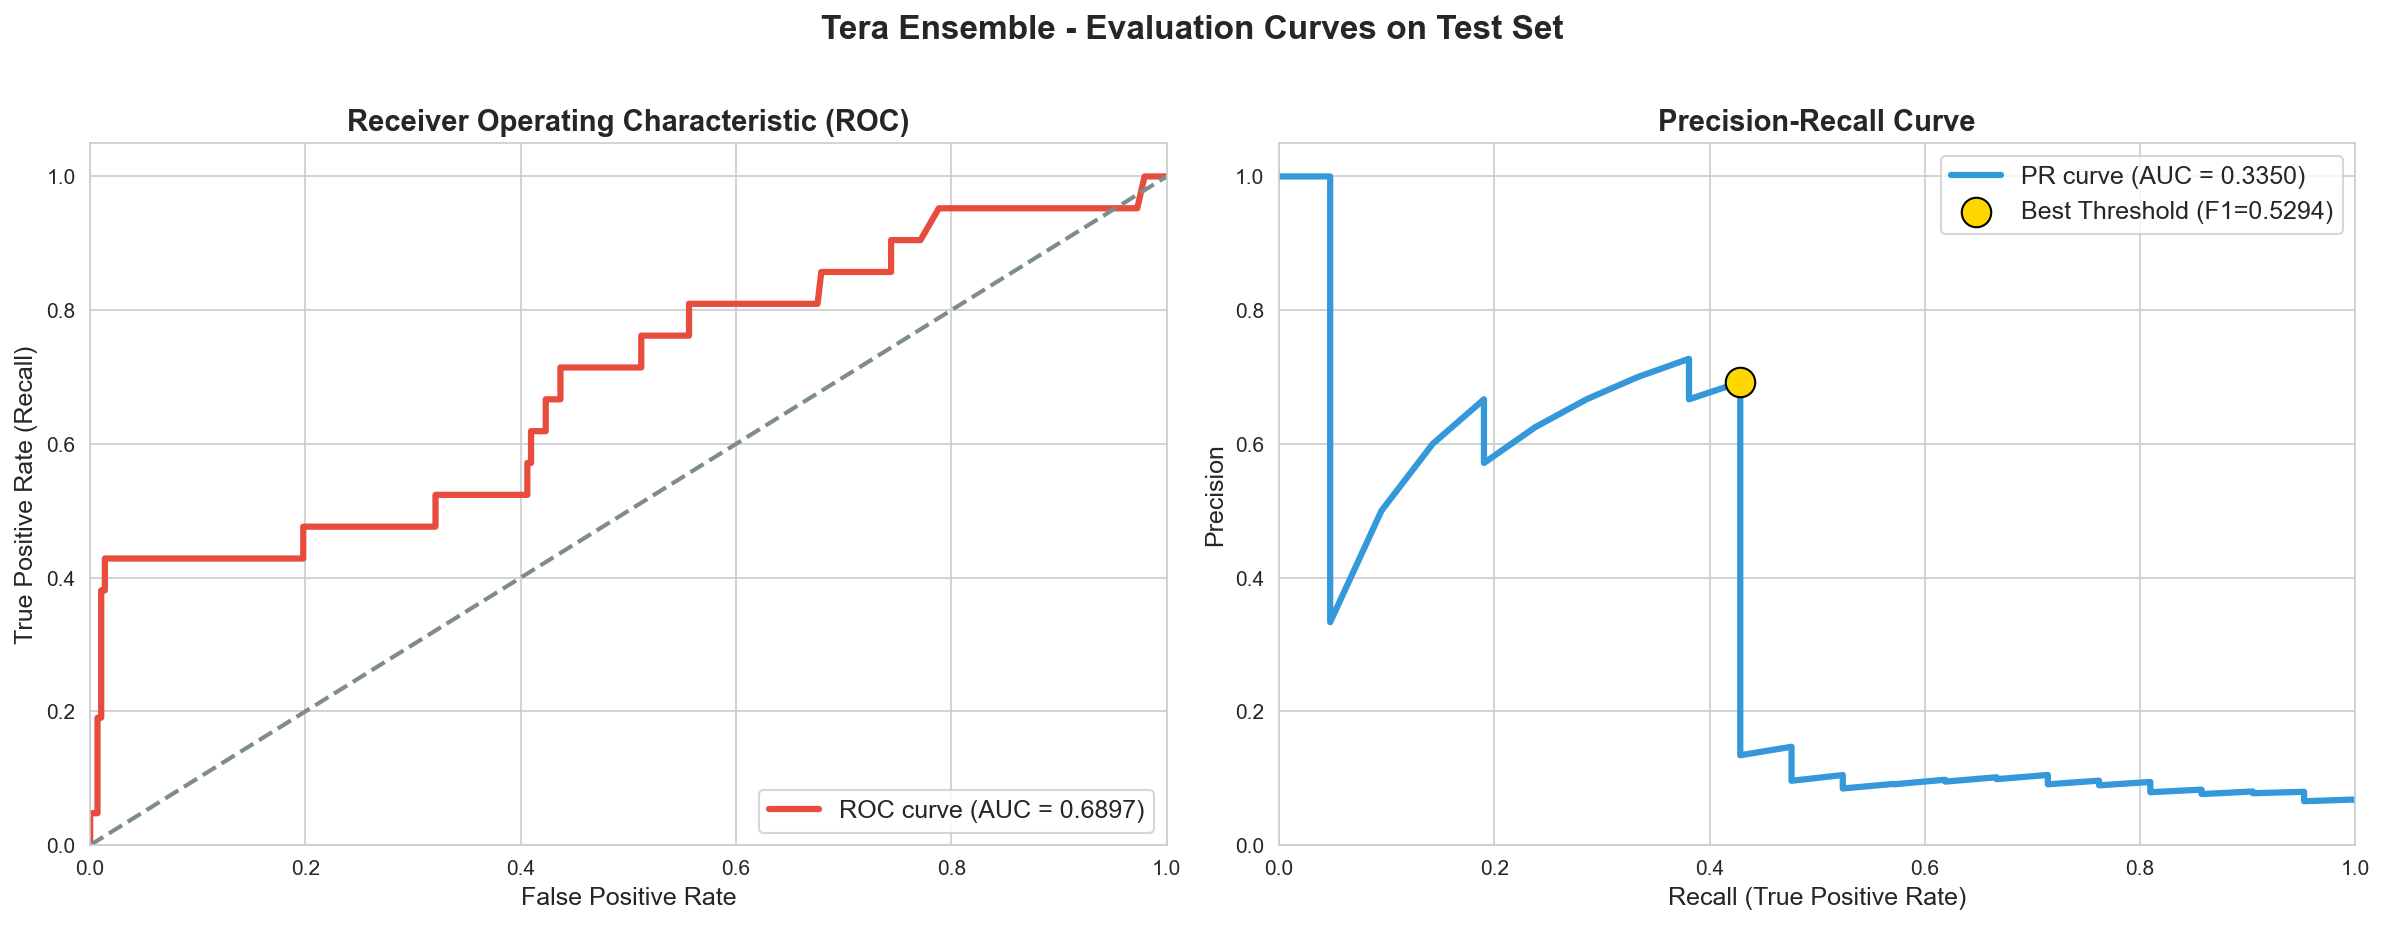

💾 viz_06_evaluation_curves.png saved


In [10]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calculate ROC Curve
fpr, tpr, _ = roc_curve(y_test, final_probs)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall Curve
pr, rc, _ = precision_recall_curve(y_test, final_probs)
pr_auc = auc(rc, pr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=12)

# 2. Precision-Recall Curve
axes[1].plot(rc, pr, color='#3498db', lw=3, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].scatter([rec], [prec], color='gold', s=200, edgecolors='black', zorder=5, label=f'Best Threshold (F1={f1:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=12)

plt.suptitle('Tera Ensemble - Evaluation Curves on Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_06_evaluation_curves.png', bbox_inches='tight')
plt.show()
print('💾 viz_06_evaluation_curves.png saved')


## 🎯 Cell 11: Ensemble Composition Donut Chart


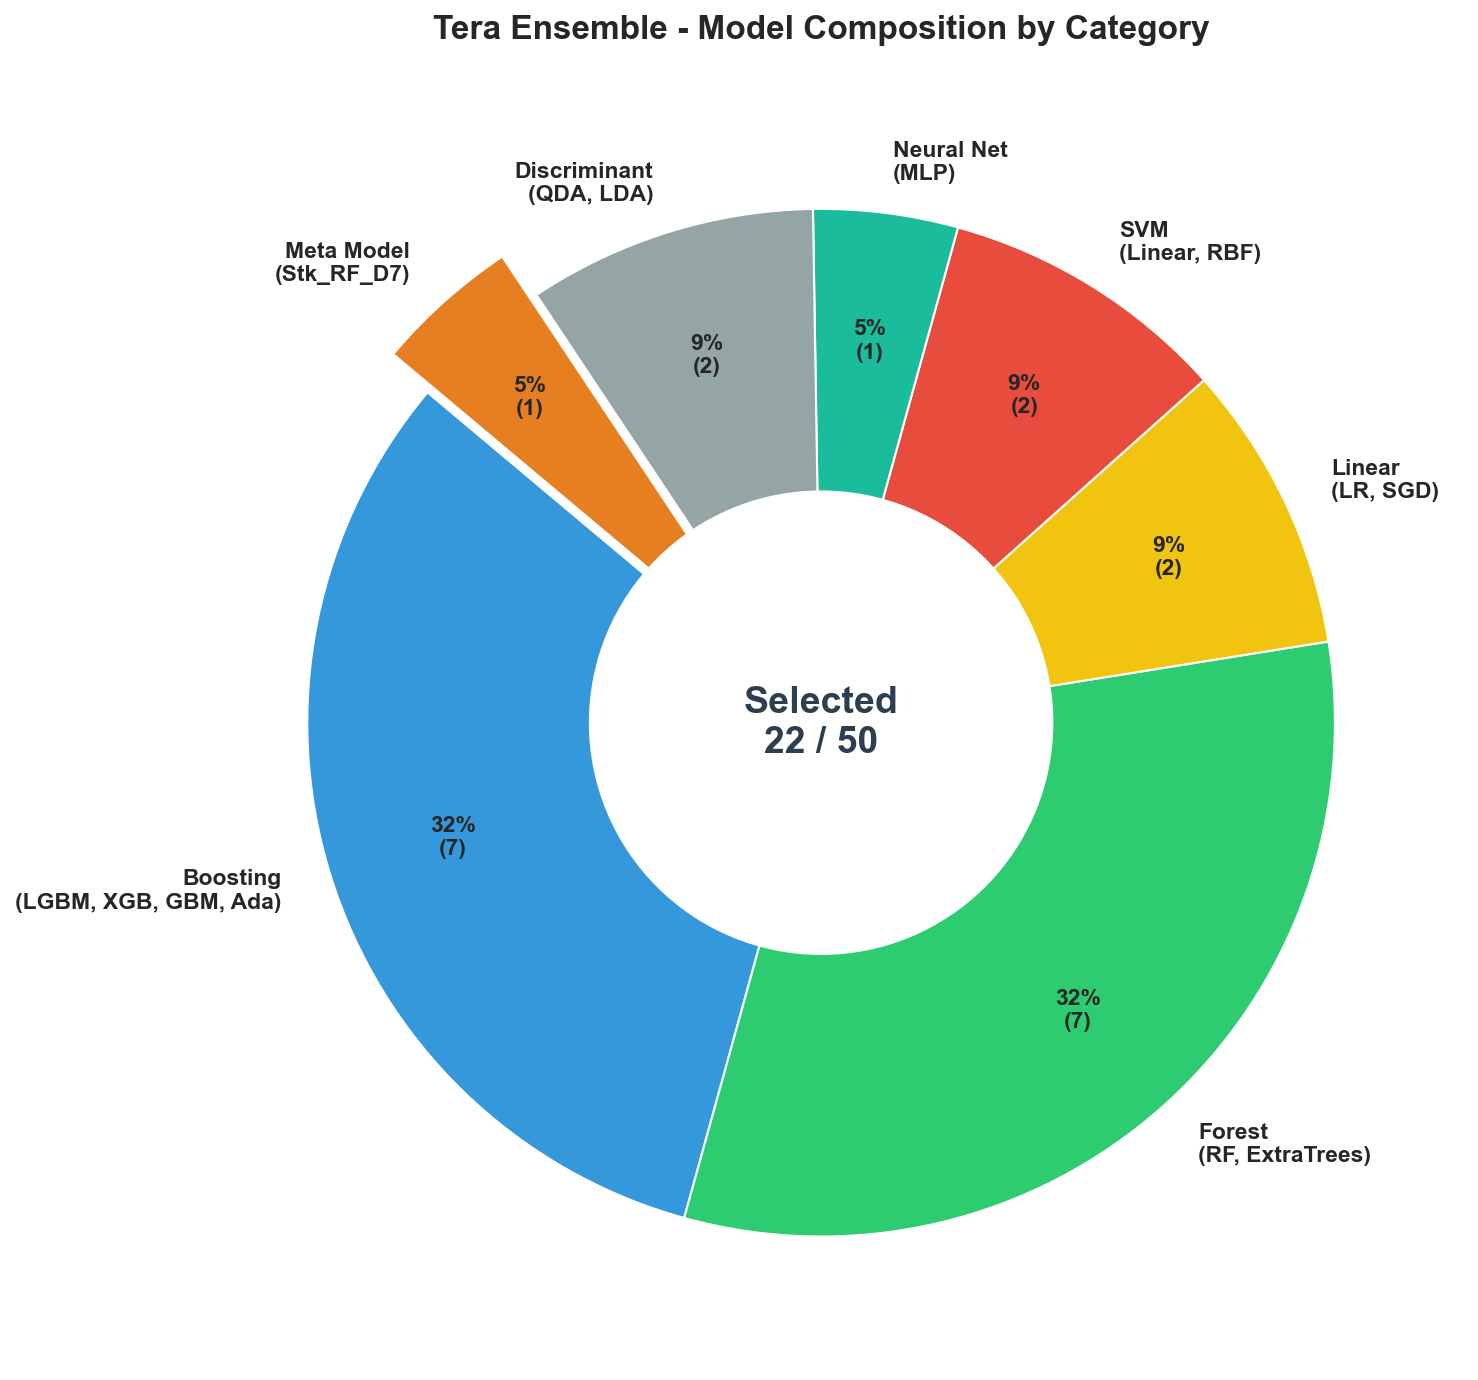

💾 viz_06_ensemble_composition.png saved


In [11]:
categories = {
    'Boosting\n(LGBM, XGB, GBM, Ada)': 7,
    'Forest\n(RF, ExtraTrees)': 7,
    'Linear\n(LR, SGD)': 2,
    'SVM\n(Linear, RBF)': 2,
    'Neural Net\n(MLP)': 1,
    'Discriminant\n(QDA, LDA)': 2,
    'Meta Model\n(Stk_RF_D7)': 1
}

labels = list(categories.keys())
sizes = list(categories.values())
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e74c3c', '#1abc9c', '#95a5a6', '#e67e22']
explode = (0, 0, 0, 0, 0, 0, 0.1)

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct=lambda pct: f'{pct:.0f}%\n({int(round(pct/100.*sum(sizes)))})',
    colors=colors, startangle=140, explode=explode,
    pctdistance=0.75, textprops={'fontsize': 11, 'fontweight': 'bold'})

centre_circle = plt.Circle((0, 0), 0.45, fc='white')
ax.add_artist(centre_circle)
ax.text(0, 0, 'Selected\n22 / 50', ha='center', va='center', fontsize=18, fontweight='bold', color='#2c3e50')
ax.set_title('Tera Ensemble - Model Composition by Category', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('viz_06_ensemble_composition.png', bbox_inches='tight')
plt.show()
print('💾 viz_06_ensemble_composition.png saved')

## 🏗️ Cell 12: 22 Selected Models - Architecture Details


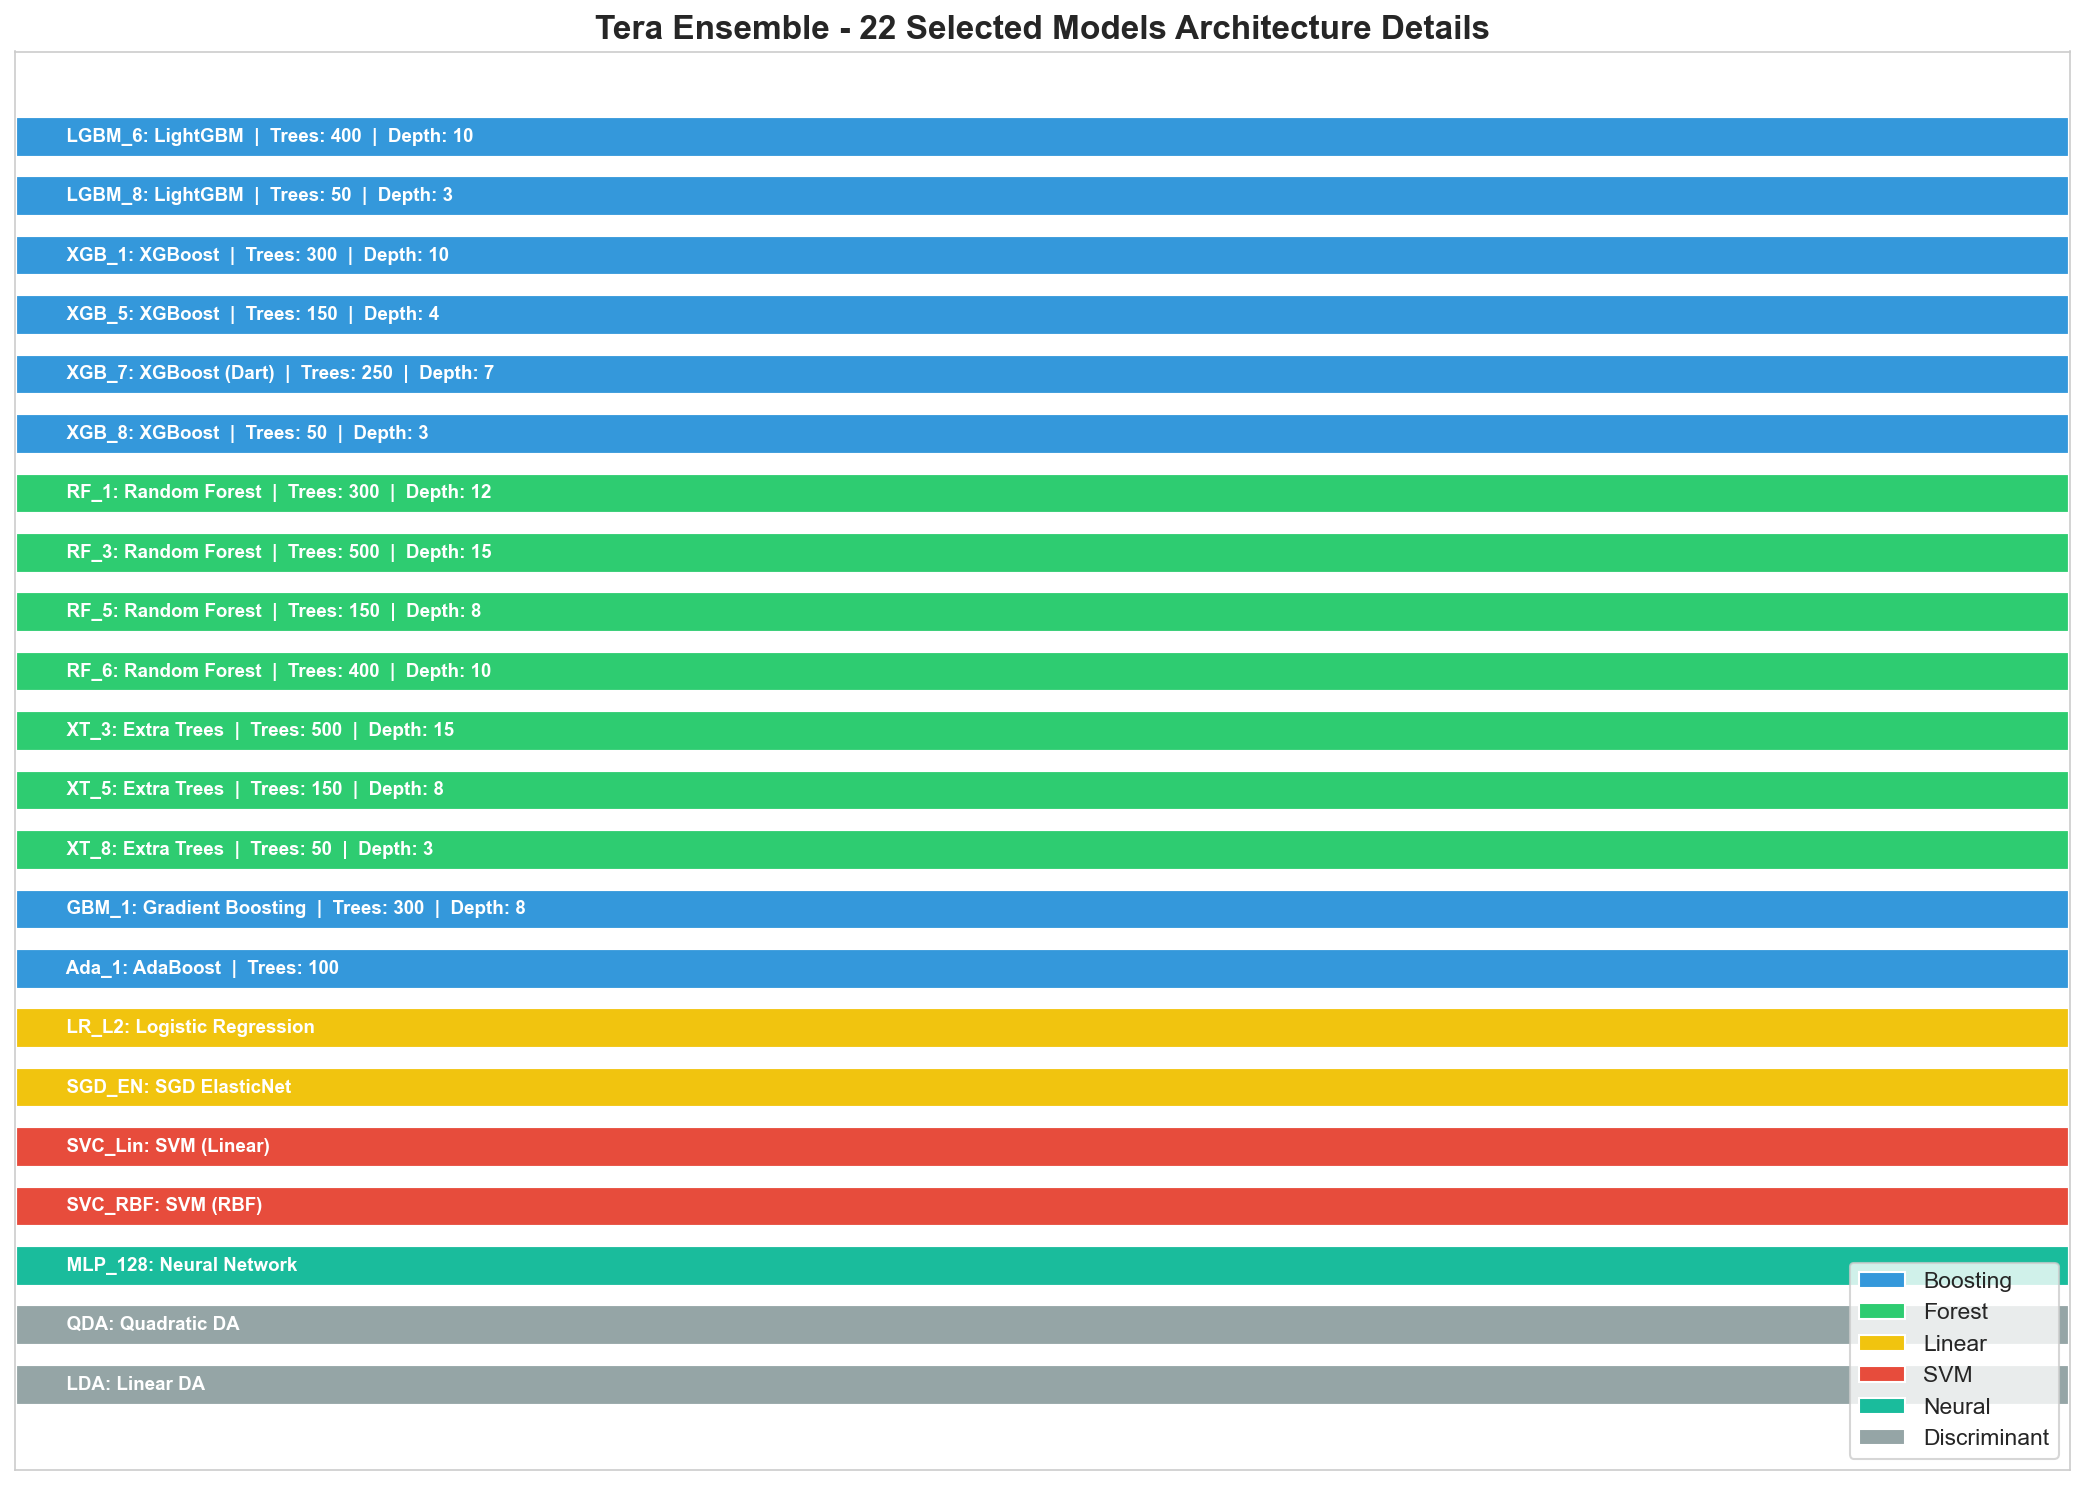

💾 viz_07_architecture_detail.png saved


In [12]:
models_info = {
    'LGBM_6': ('LightGBM', 400, 10, 'Boosting'),
    'LGBM_8': ('LightGBM', 50, 3, 'Boosting'),
    'XGB_1': ('XGBoost', 300, 10, 'Boosting'),
    'XGB_5': ('XGBoost', 150, 4, 'Boosting'),
    'XGB_7': ('XGBoost (Dart)', 250, 7, 'Boosting'),
    'XGB_8': ('XGBoost', 50, 3, 'Boosting'),
    'RF_1': ('Random Forest', 300, 12, 'Forest'),
    'RF_3': ('Random Forest', 500, 15, 'Forest'),
    'RF_5': ('Random Forest', 150, 8, 'Forest'),
    'RF_6': ('Random Forest', 400, 10, 'Forest'),
    'XT_3': ('Extra Trees', 500, 15, 'Forest'),
    'XT_5': ('Extra Trees', 150, 8, 'Forest'),
    'XT_8': ('Extra Trees', 50, 3, 'Forest'),
    'GBM_1': ('Gradient Boosting', 300, 8, 'Boosting'),
    'Ada_1': ('AdaBoost', 100, '-', 'Boosting'),
    'LR_L2': ('Logistic Regression', '-', '-', 'Linear'),
    'SGD_EN': ('SGD ElasticNet', '-', '-', 'Linear'),
    'SVC_Lin': ('SVM (Linear)', '-', '-', 'SVM'),
    'SVC_RBF': ('SVM (RBF)', '-', '-', 'SVM'),
    'MLP_128': ('Neural Network', '-', '-', 'Neural'),
    'QDA': ('Quadratic DA', '-', '-', 'Discriminant'),
    'LDA': ('Linear DA', '-', '-', 'Discriminant'),
}

category_colors = {'Boosting': '#3498db', 'Forest': '#2ecc71', 'Linear': '#f1c40f',
                   'SVM': '#e74c3c', 'Neural': '#1abc9c', 'Discriminant': '#95a5a6'}

fig, ax = plt.subplots(figsize=(14, 10))
model_labels = list(models_info.keys())
y_pos = np.arange(len(model_labels))
bar_colors = [category_colors[models_info[m][3]] for m in model_labels]

bars = ax.barh(y_pos, [1]*len(model_labels), color=bar_colors, edgecolor='white', linewidth=2, height=0.7)

for i, (name, (algo, n_est, depth, cat)) in enumerate(models_info.items()):
    info_text = f'{algo}'
    if n_est != '-':
        info_text += f'  |  Trees: {n_est}'
    if depth != '-':
        info_text += f'  |  Depth: {depth}'
    ax.text(0.02, i, f'  {name}: {info_text}', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Tera Ensemble - 22 Selected Models Architecture Details', fontsize=16, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in category_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

ax.invert_yaxis()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('viz_07_architecture_detail.png', bbox_inches='tight')
plt.show()
print('💾 viz_07_architecture_detail.png saved')

## 🔬 Cell 13: Model Selection - 50 Candidates → 22 Winners


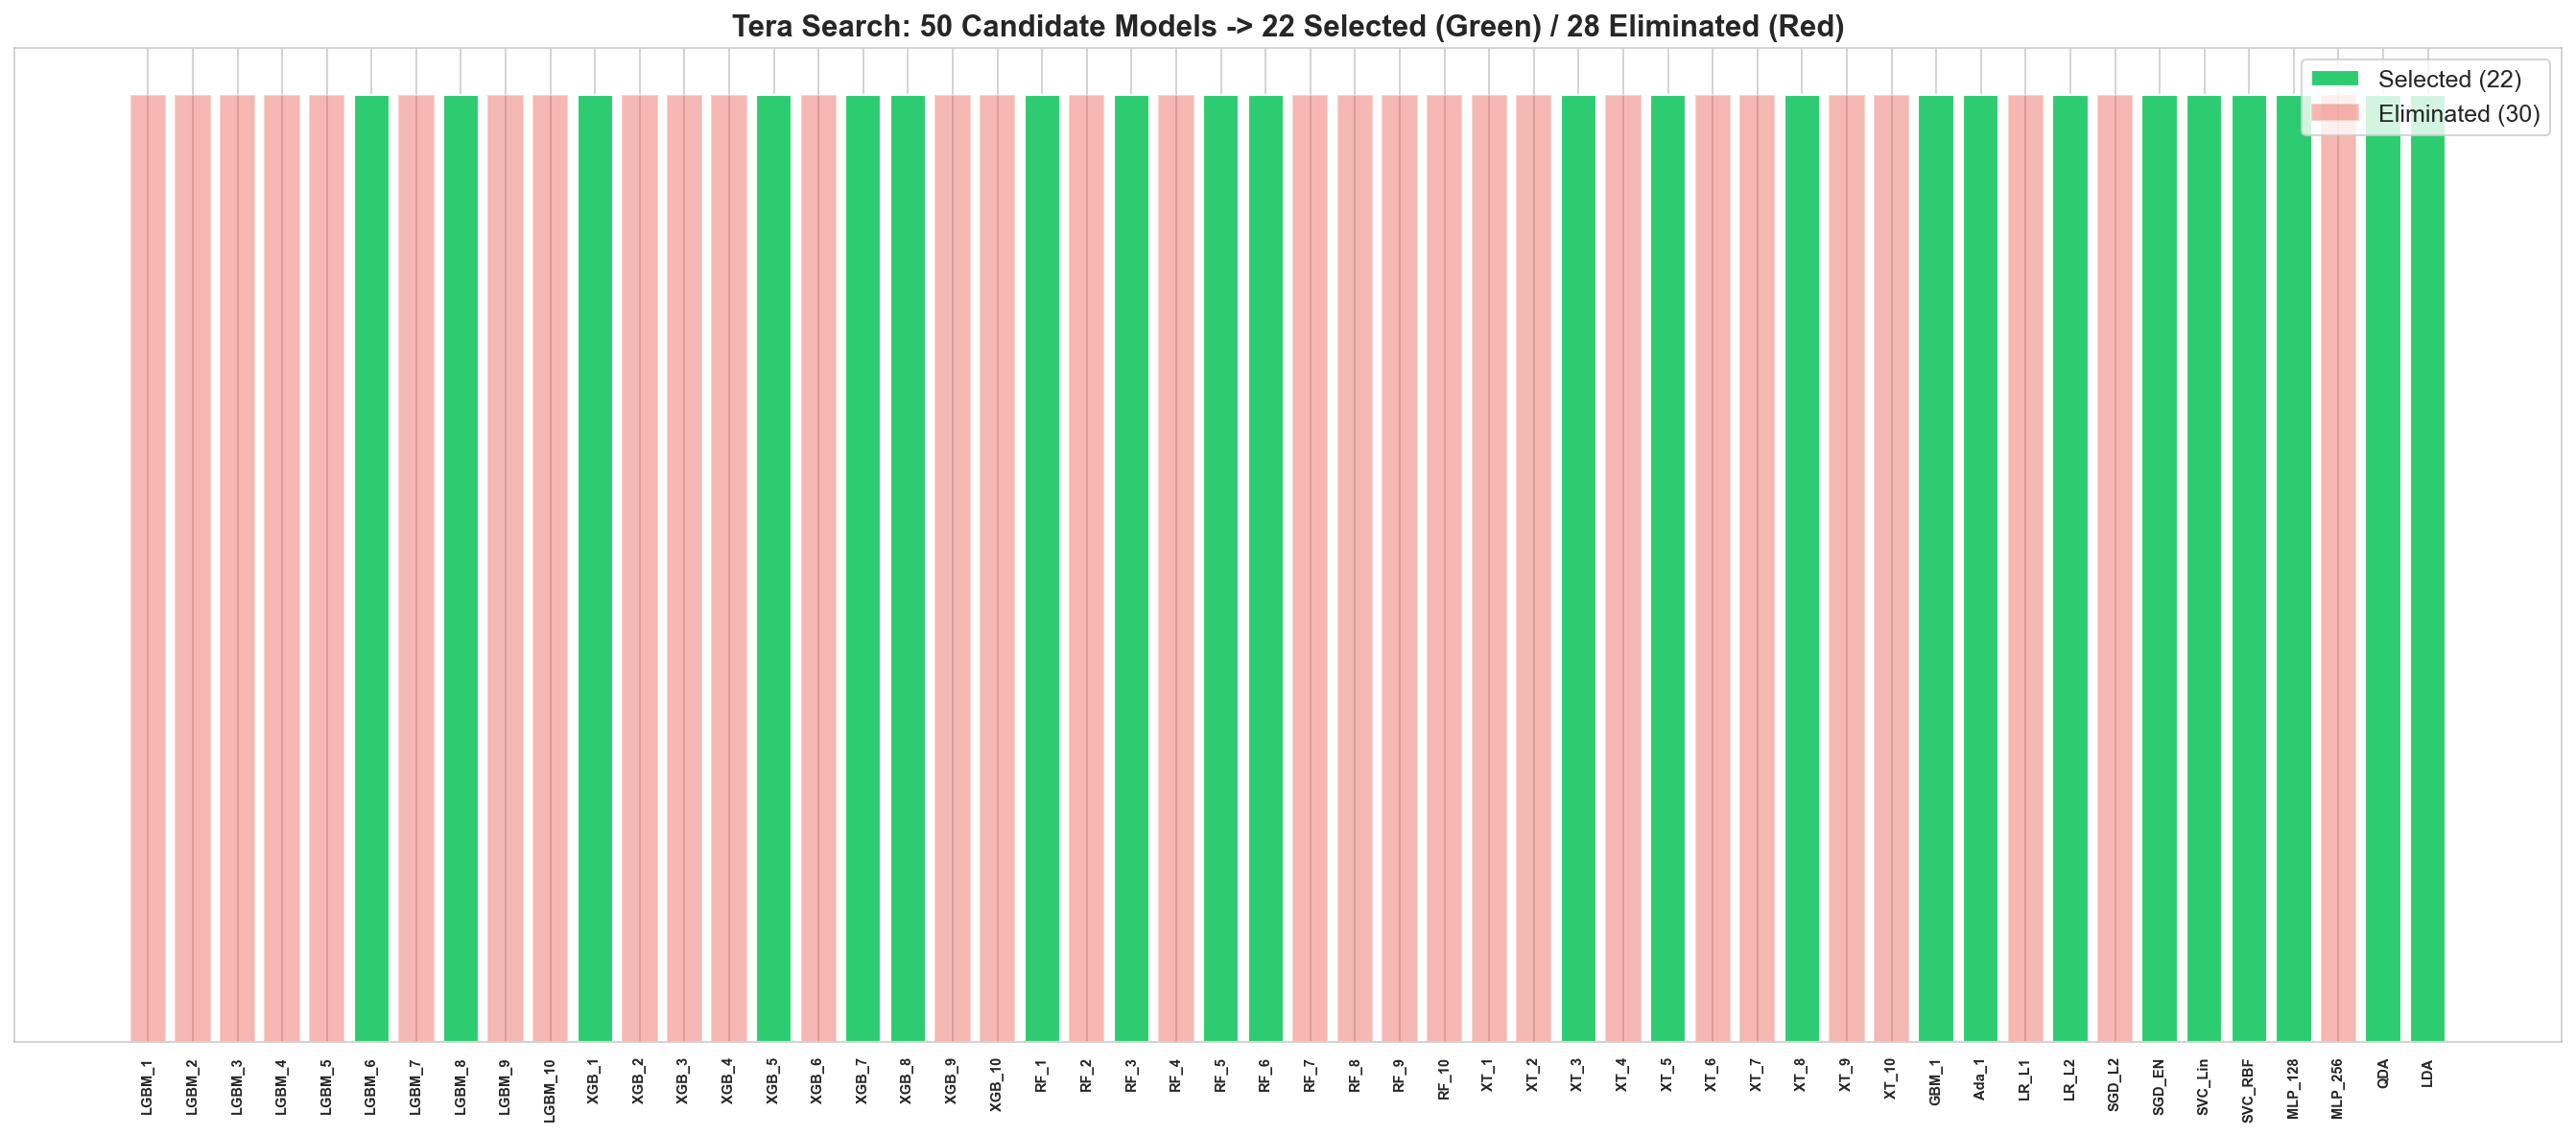

💾 viz_08_model_selection.png saved


In [13]:
# 50 candidate models: 22 selected, 28 eliminated
all_models = {
    'LGBM_1': False, 'LGBM_2': False, 'LGBM_3': False, 'LGBM_4': False, 'LGBM_5': False,
    'LGBM_6': True, 'LGBM_7': False, 'LGBM_8': True, 'LGBM_9': False, 'LGBM_10': False,
    'XGB_1': True, 'XGB_2': False, 'XGB_3': False, 'XGB_4': False, 'XGB_5': True,
    'XGB_6': False, 'XGB_7': True, 'XGB_8': True, 'XGB_9': False, 'XGB_10': False,
    'RF_1': True, 'RF_2': False, 'RF_3': True, 'RF_4': False, 'RF_5': True,
    'RF_6': True, 'RF_7': False, 'RF_8': False, 'RF_9': False, 'RF_10': False,
    'XT_1': False, 'XT_2': False, 'XT_3': True, 'XT_4': False, 'XT_5': True,
    'XT_6': False, 'XT_7': False, 'XT_8': True, 'XT_9': False, 'XT_10': False,
    'GBM_1': True, 'Ada_1': True,
    'LR_L1': False, 'LR_L2': True, 'SGD_L2': False, 'SGD_EN': True,
    'SVC_Lin': True, 'SVC_RBF': True,
    'MLP_128': True, 'MLP_256': False,
    'QDA': True, 'LDA': True
}

names = list(all_models.keys())
selected = list(all_models.values())
bar_colors = ['#2ecc71' if s else '#e74c3c' for s in selected]
bar_alpha = [1.0 if s else 0.4 for s in selected]

fig, ax = plt.subplots(figsize=(18, 8))
x = np.arange(len(names))
bars = ax.bar(x, [1]*len(names), color=bar_colors, edgecolor='white', linewidth=1)
for bar, a in zip(bars, bar_alpha):
    bar.set_alpha(a)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=90, fontsize=7, fontweight='bold')
ax.set_yticks([])
ax.set_title(f'Tera Search: 50 Candidate Models -> 22 Selected (Green) / 28 Eliminated (Red)',
             fontsize=15, fontweight='bold')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#2ecc71', label=f'Selected ({sum(selected)})'),
                Patch(facecolor='#e74c3c', alpha=0.4, label=f'Eliminated ({len(selected)-sum(selected)})')]
ax.legend(handles=legend_elems, fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig('viz_08_model_selection.png', bbox_inches='tight')
plt.show()
print('💾 viz_08_model_selection.png saved')

## 📊 Cell 14: Stacking Ensemble Architecture Diagram


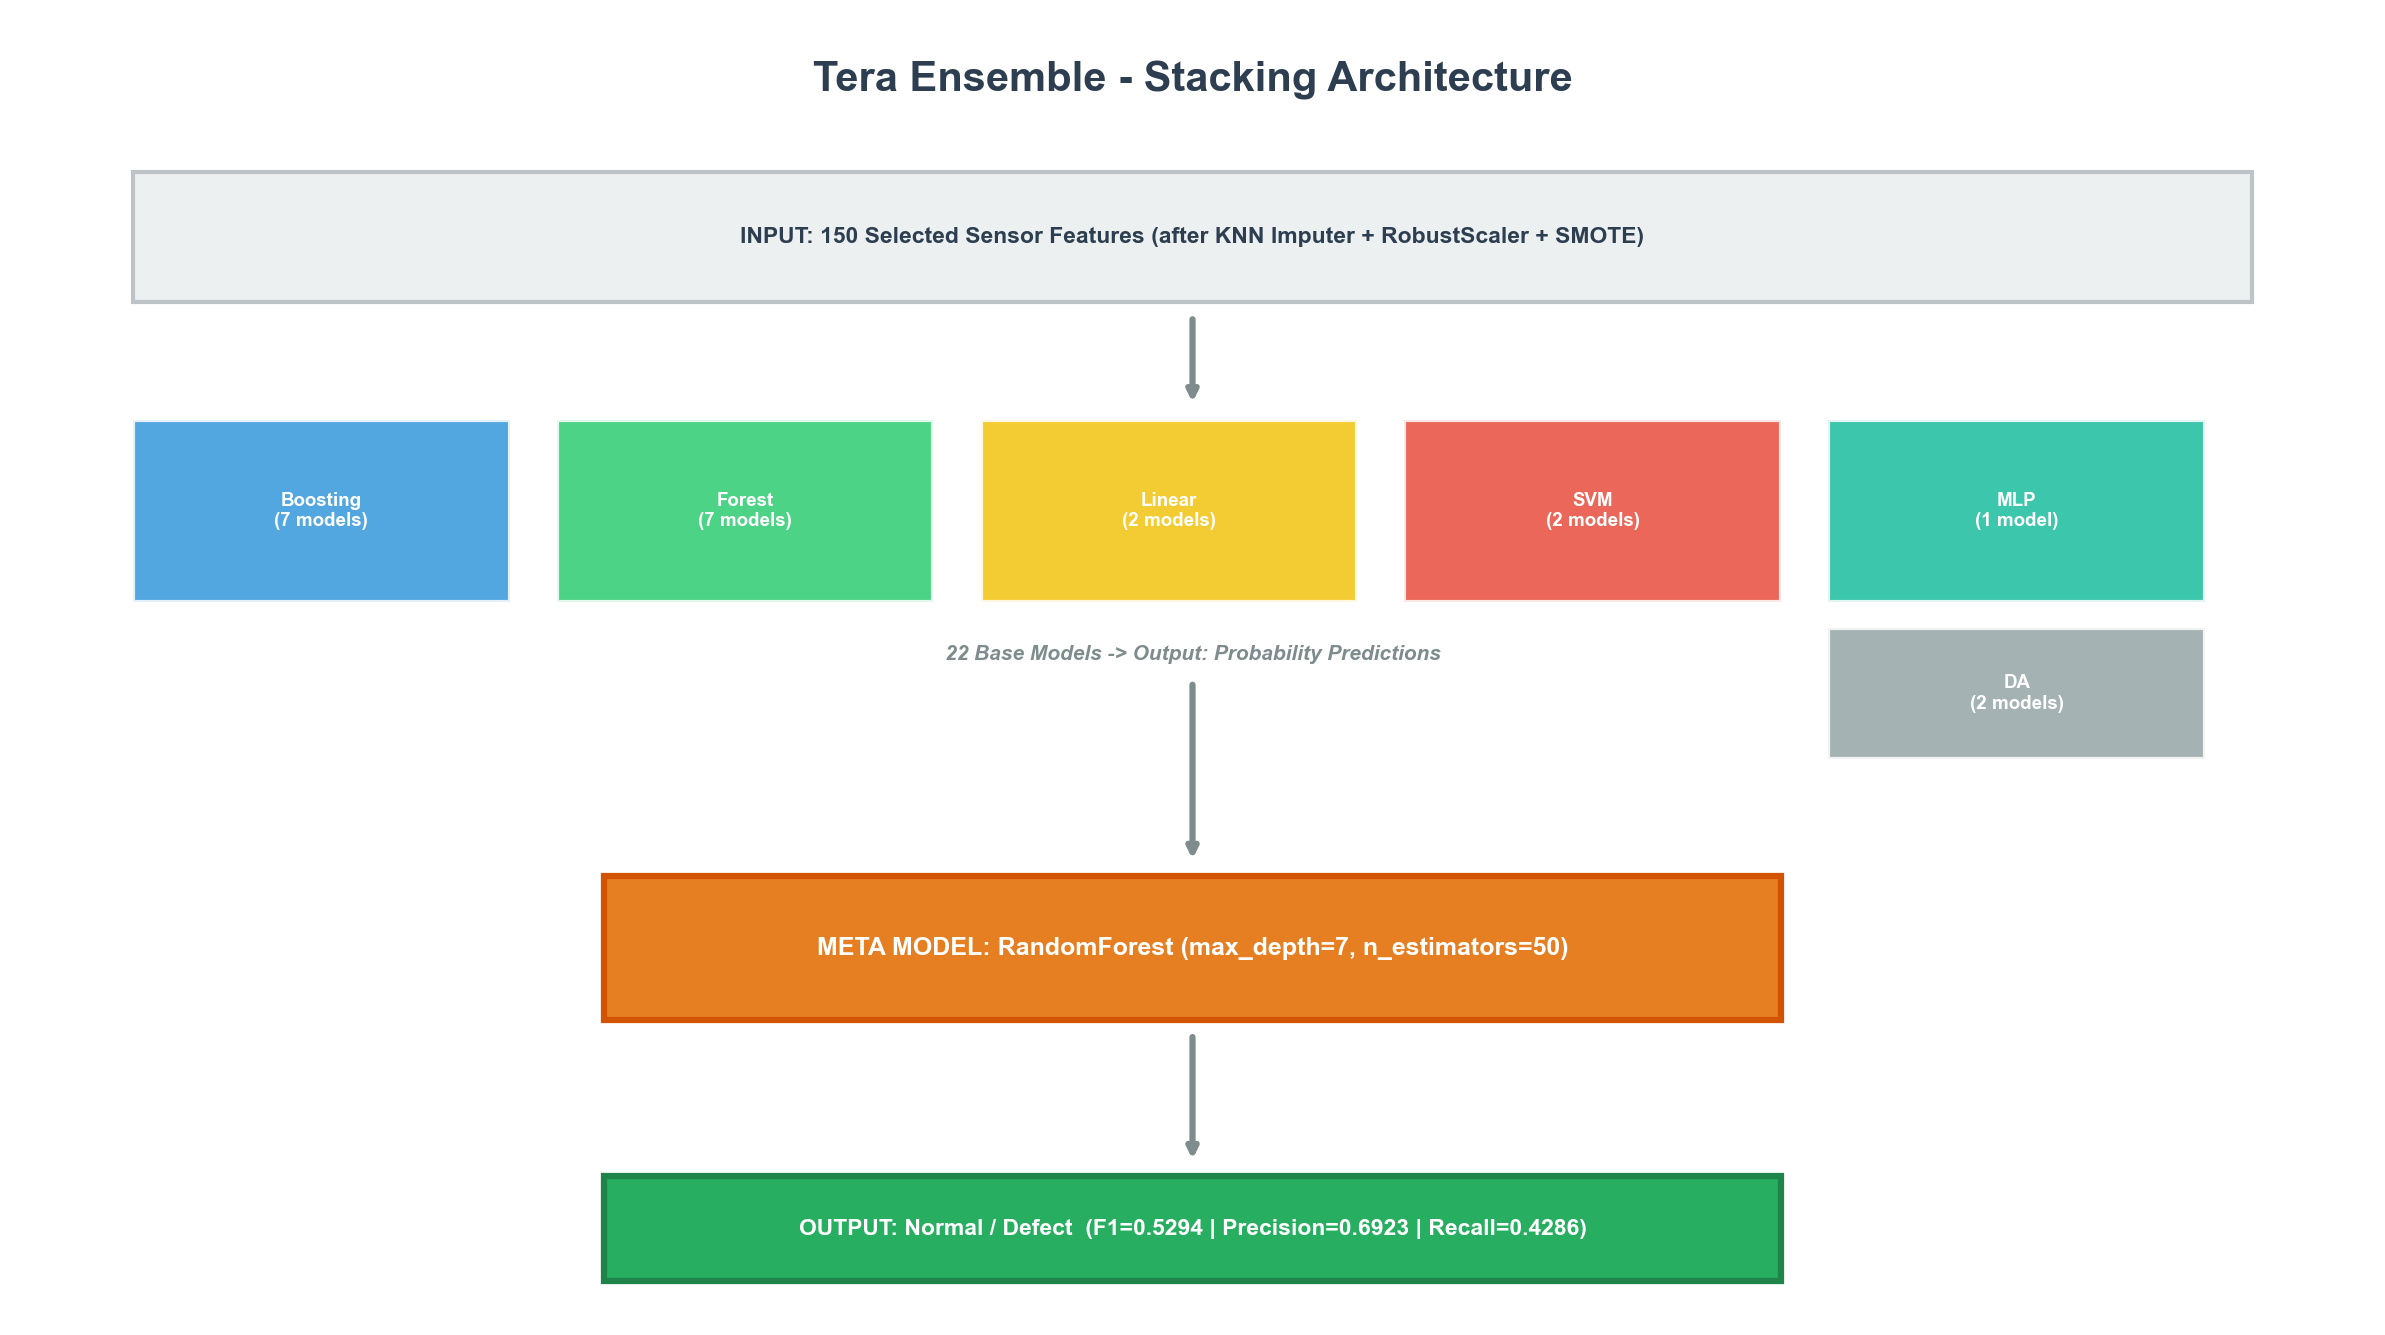

💾 viz_09_stacking_architecture.png saved


In [14]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Tera Ensemble - Stacking Architecture', fontsize=20, fontweight='bold',
        ha='center', va='center', color='#2c3e50')

# Layer 1: Input
input_box = plt.Rectangle((0.5, 7.8), 9, 1.0, facecolor='#ecf0f1', edgecolor='#bdc3c7', linewidth=2, zorder=2)
ax.add_patch(input_box)
ax.text(5, 8.3, 'INPUT: 150 Selected Sensor Features (after KNN Imputer + RobustScaler + SMOTE)',
        fontsize=11, fontweight='bold', ha='center', va='center', color='#2c3e50')

# Arrow
ax.annotate('', xy=(5, 7.0), xytext=(5, 7.7),
           arrowprops=dict(arrowstyle='->', lw=3, color='#7f8c8d'))

# Layer 2: Base Models
base_categories = [
    ('Boosting\n(7 models)', '#3498db', 0.5),
    ('Forest\n(7 models)', '#2ecc71', 2.3),
    ('Linear\n(2 models)', '#f1c40f', 4.1),
    ('SVM\n(2 models)', '#e74c3c', 5.9),
    ('MLP\n(1 model)', '#1abc9c', 7.7),
]

for label, color, xpos in base_categories:
    box = plt.Rectangle((xpos, 5.5), 1.6, 1.4, facecolor=color, edgecolor='white',
                        linewidth=2, zorder=2, alpha=0.85)
    ax.add_patch(box)
    ax.text(xpos + 0.8, 6.2, label, fontsize=9, fontweight='bold',
           ha='center', va='center', color='white')

# DA models
box = plt.Rectangle((7.7, 4.3), 1.6, 1.0, facecolor='#95a5a6', edgecolor='white',
                    linewidth=2, zorder=2, alpha=0.85)
ax.add_patch(box)
ax.text(8.5, 4.8, 'DA\n(2 models)', fontsize=9, fontweight='bold',
       ha='center', va='center', color='white')

ax.text(5, 5.1, '22 Base Models -> Output: Probability Predictions',
       fontsize=10, fontweight='bold', ha='center', va='center', color='#7f8c8d', style='italic')

# Arrow
ax.annotate('', xy=(5, 3.5), xytext=(5, 4.9),
           arrowprops=dict(arrowstyle='->', lw=3, color='#7f8c8d'))

# Layer 3: Meta Model
meta_box = plt.Rectangle((2.5, 2.3), 5, 1.1, facecolor='#e67e22', edgecolor='#d35400',
                         linewidth=3, zorder=2)
ax.add_patch(meta_box)
ax.text(5, 2.85, 'META MODEL: RandomForest (max_depth=7, n_estimators=50)',
       fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Arrow
ax.annotate('', xy=(5, 1.2), xytext=(5, 2.2),
           arrowprops=dict(arrowstyle='->', lw=3, color='#7f8c8d'))

# Layer 4: Output
output_box = plt.Rectangle((2.5, 0.3), 5, 0.8, facecolor='#27ae60', edgecolor='#1e8449',
                           linewidth=3, zorder=2)
ax.add_patch(output_box)
ax.text(5, 0.7, 'OUTPUT: Normal / Defect  (F1=0.5294 | Precision=0.6923 | Recall=0.4286)',
       fontsize=11, fontweight='bold', ha='center', va='center', color='white')

plt.tight_layout()
plt.savefig('viz_09_stacking_architecture.png', bbox_inches='tight')
plt.show()
print('💾 viz_09_stacking_architecture.png saved')

## 🔢 Cell 15: Tera Search Scale Summary


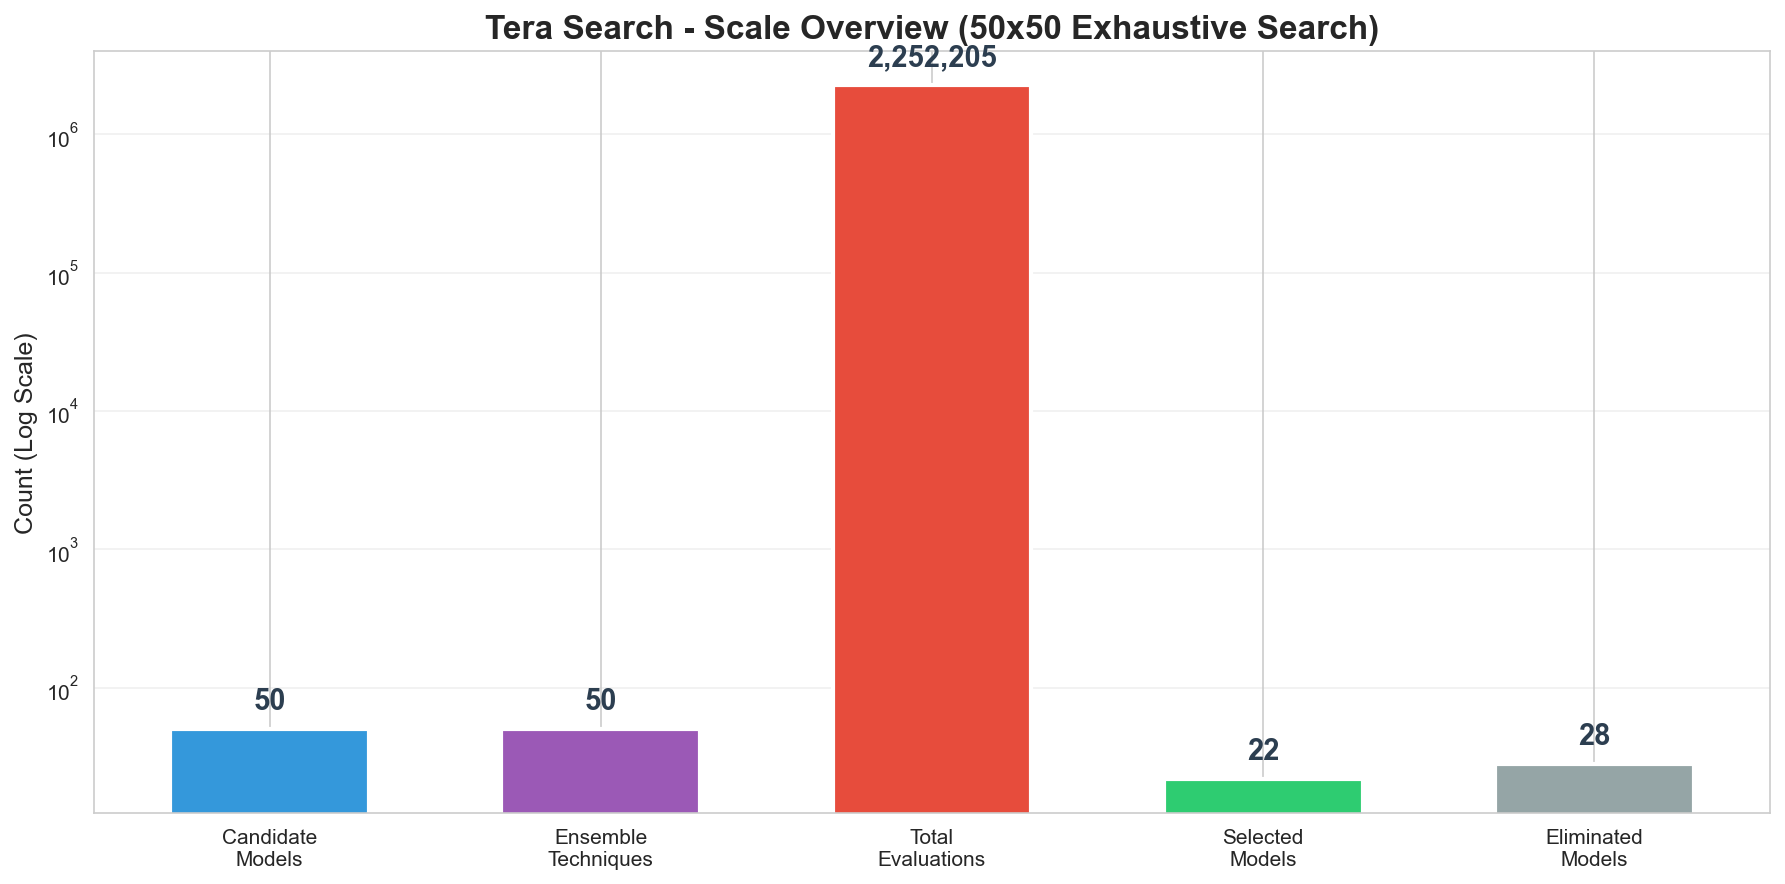

💾 viz_10_tera_search_scale.png saved


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Tera Search stats
stats_labels = ['Candidate\nModels', 'Ensemble\nTechniques', 'Total\nEvaluations',
                'Selected\nModels', 'Eliminated\nModels']
stats_values = [50, 50, 2252205, 22, 28]
stats_colors = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71', '#95a5a6']

bars = ax.bar(stats_labels, stats_values, color=stats_colors, edgecolor='white', linewidth=2, width=0.6)
ax.set_yscale('log')
ax.set_ylabel('Count (Log Scale)', fontsize=12)
ax.set_title('Tera Search - Scale Overview (50x50 Exhaustive Search)', fontsize=16, fontweight='bold')

for bar, val in zip(bars, stats_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.4,
           f'{val:,}', ha='center', fontsize=14, fontweight='bold', color='#2c3e50')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_10_tera_search_scale.png', bbox_inches='tight')
plt.show()
print('💾 viz_10_tera_search_scale.png saved')

## 🏆 Cell 16: Final Report Card


In [16]:
print('=' * 70)
print('  🏆 SECOM Defect Detection - Tera Ensemble Final Report 🏆')
print('=' * 70)
print(f'\n  📐 Dataset:     1,567 Rows x 592 Cols (0 Rows Deleted)')
print(f'  🚿 Pipeline:    KNN Imputer -> Feature Selection -> RobustScaler -> SMOTE')
print(f'  🔍 Search:      50 Models x 50 Ensemble Techniques = 2,252,205 Evaluations')
print(f'  🤖 Selected:    22 / 50 Models (28 Eliminated by Tera Search)')
print(f'  🧠 Technique:   Stacking (Meta: RandomForest, max_depth=7)')
print(f'\n  ┌─────────────────────────────────────────────────┐')
print(f'  │  F1-Score    :  {f1:.4f}                          │')
print(f'  │  Precision   :  {prec:.4f}                          │')
print(f'  │  Recall      :  {rec:.4f}                          │')
print(f'  │  Accuracy    :  {acc:.4f}                          │')
print(f'  │  Specificity :  {spec:.4f}                          │')
print(f'  └─────────────────────────────────────────────────┘')
print(f'\n  📊 Confusion Matrix (Test Set, n=314):')
print(f'                   Pred Normal  Pred Defect')
print(f'  True Normal          {tn:<13d}{fp:<13d}')
print(f'  True Defect           {fn:<13d}{tp:<13d}')
print(f'\n  💡 Insight: When alarm triggers, {prec*100:.1f}% chance of real defect!')
print(f'             Caught {tp} of {tp+fn} defects, with only {fp} false alarms.')
print('\n' + '=' * 70)
print('\n📁 Saved Visualization Files:')
import glob
for f in sorted(glob.glob('viz_*.png')):
    print(f'   📊 {f}')
print('\n✅ All visualizations generated successfully!')

  🏆 SECOM Defect Detection - Tera Ensemble Final Report 🏆

  📐 Dataset:     1,567 Rows x 592 Cols (0 Rows Deleted)
  🚿 Pipeline:    KNN Imputer -> Feature Selection -> RobustScaler -> SMOTE
  🔍 Search:      50 Models x 50 Ensemble Techniques = 2,252,205 Evaluations
  🤖 Selected:    22 / 50 Models (28 Eliminated by Tera Search)
  🧠 Technique:   Stacking (Meta: RandomForest, max_depth=7)

  ┌─────────────────────────────────────────────────┐
  │  F1-Score    :  0.5294                          │
  │  Precision   :  0.6923                          │
  │  Recall      :  0.4286                          │
  │  Accuracy    :  0.9490                          │
  │  Specificity :  0.9863                          │
  └─────────────────────────────────────────────────┘

  📊 Confusion Matrix (Test Set, n=314):
                   Pred Normal  Pred Defect
  True Normal          289          4            
  True Defect           12           9            

  💡 Insight: When alarm triggers, 69.2% chanc